# 3. Trend analysis observations Notebook
## 3a. Probabilistic method

---

## How to Use This Notebook

**1. Follow the numbered steps in order.**  
Each section builds upon the previous one, from setup, data loading, and climatology computation, to event analysis and visualization.

**2. Look for <font color="orange"> Orange cells  </font> and code cells marked as <font color="lightgreen">##### (User selection) ##### </font>:** 
| <font color="orange"> Orange cells  </font> | <font color="orange"> Need user intervantion </font>|
| ----------- | ----------- |
| <font color="green">**Green cells** </font> | <font color="green">**Run automatically on user input provided in the orange cells and should not be adjusted in most cases** </font>|


**3. Run cells sequentially.**  
Start from the top and execute each cell (`Shift` + `Enter`).  

### <font color="green"> Import require packages </font>

In [1]:
from datetime import datetime, timedelta
from c3s_event_attribution_tools import Plot, Utils, DataClient, Process
import xarray as xr
import pandas as pd
import geopandas as gpd
import os
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
import numpy as np
from typing import Literal, Union
from scipy.stats import chi2
from matplotlib import pyplot as plt
from matplotlib import dates as mdates 

# import R libraries from WWA
ro.r('''if (!requireNamespace("devtools", quietly = TRUE)) {install.packages("devtools", repos="https://cloud.r-project.org", quiet=TRUE)}''')
ro.r('devtools::install_github("WorldWeatherAttribution/rwwa")')
rwwa = importr("rwwa")
%load_ext rpy2.ipython

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.
R callback write-console: Using GitHub PAT from the git credential store.
  
R callback write-console: Skipping install of 'rwwa' from a github remote, the SHA1 (236d9a6b) has not changed since last install.
  Use `force = TRUE` to force installation
  


### <font color="orange"> User specifications </font>

In [2]:
# Directory you wish to store output files in. using ../ specifies the parent directory
CURRENT_DIRECTORY = os.getcwd() # do not touch, __file__ specifies the current directory of the file

################# (User selection) ###################
your_save_directory = os.path.abspath(os.path.join(CURRENT_DIRECTORY, "../data"))   # change ../data to your desired directory
######################################################

### <font color="orange"> Choice of parameter </font>

In [3]:
# Choice of parameter (Tmax, Tmean, Tmin, Precipitation)
################# (User selection) ###################
parameter = "Precipitation" 
event_end = datetime(2025, 10, 10) 
bbox = (15, -104, 28, -90)

######################################################
event_start = event_end - timedelta(days=14)
bbox = Utils.convert_bbox(*bbox)
event_year = datetime(2025, 10, 10).year
######################################################

# Setting up the parameter specific variables
if parameter in ["Tmax", "Tmean", "Tmin"]:
    variable = "Temperature"
    value_col = "t2m"
    y_label = "c"
    unit = "°C"
    calculation = "absolute"  # absolute or relative
    method = "std" 
elif parameter == "Precipitation":
    variable = "Precipitation"
    value_col = "tp"
    y_label = "mm"
    unit = "mm"
    calculation = "relative"  # absolute or relative
    method = "dispersion"

## 3.2 Check (visually) for inhomogeneity of annual event time series

### <font color='orange'>Please specify the file name of the annual time series from the event definition step</font>

In [4]:
################# (User selection) ###################
annual_timeseries_load = 'ts_ann_studyregion 1.nc'
######################################################

ts_ann_studyregion = xr.open_dataset(os.path.join(your_save_directory, annual_timeseries_load)).to_dataframe().reset_index()
ts_ann_studyregion

,year,3_day_rolling_date,tp
0,1951,1951-08-23,72.611237
1,1952,1952-06-03,156.611115
2,1953,1953-10-05,56.201640
3,1954,1954-10-08,197.463386
4,1955,1955-09-30,209.504221
...,...,...,...
70,2021,2021-08-21,99.719591
71,2022,2022-06-21,56.343547
72,2023,2023-10-07,91.881753
73,2024,2024-07-01,127.713241


- a. Pay special attention to years that might coincide with key events such as the introduction of satellites
    - i. 1979 (start of satellite era)
    - ii. Tropical precipitation: 1998 (start of better tropical satellite data)
- b. Jumps in the (annual) time series
- c. visually check the scale or dispersion parameter (running standard deviation)

In [5]:
def calculate_rolling_window_test(
    gdf: Union[pd.DataFrame, gpd.GeoDataFrame],
    value_col: str,
    window: int,
    centering: bool = False,
    datetime_col: str = "valid_time",
    method: Literal["sum", "mean", "std", "quantile", "dispersion"] = "mean",
    quantile: float = 0.9,
    group_by: list[str]|None = None,
    min_periods: int|None = 1,
    remove_leap_days: bool = False,
    ci: bool = False,
    ci_level: float = 0.95,
):
    """
    Compute rolling statistics (sum, mean, std, quantile) over a fixed-size window.
    Assumes datetime_col is already at the desired temporal resolution (days, months, or years).

    Returns
    -------
    DataFrame or GeoDataFrame
        Same as input, with rolled values in `value_col`.
    """

    if window <= 1:
        return gdf

    gdf = gdf.copy()

    if remove_leap_days:
        # Ensure datetime_col is datetime (should already be if user promised so)
        gdf[datetime_col] = pd.to_datetime(gdf[datetime_col])

        # Drop Feb 29 for yearly data consistency (optional)
        gdf = gdf[~((gdf[datetime_col].dt.month == 2) & (gdf[datetime_col].dt.day == 29))]

    if group_by is None:
        group_by = []

    def apply_roll(group):
        group = group.sort_values(datetime_col)
        roller = group[value_col].rolling(window=window, min_periods=min_periods, center=centering)

        match method:
            case "sum":
                rolled = roller.sum()
            case "mean":
                rolled = roller.mean()
            case "std":
                rolled = roller.std()
            case "quantile":
                rolled = roller.quantile(quantile)
            case "dispersion":
                rolled = roller.std() / roller.mean()
            case _:
                raise ValueError(f"Unsupported method: {method}")

        group[value_col] = rolled
        
        if ci and method in ("std", "dispersion"):
            n = roller.count().reset_index(drop=True)
            alpha = 1 - ci_level
            var = roller.var().reset_index(drop=True)

            chi2_lower = chi2.ppf(1 - alpha / 2, n - 1)
            chi2_upper = chi2.ppf(alpha / 2, n - 1)
            std_lower = np.sqrt((n - 1) * var / chi2_lower)
            std_upper = np.sqrt((n - 1) * var / chi2_upper)

            if method == "std":
                group[f"{value_col}_ci_lower"] = std_lower
                group[f"{value_col}_ci_upper"] = std_upper

            elif method == "dispersion":
                mean_vals = roller.mean().reset_index(drop=True)
                mean_vals = mean_vals.replace(0, np.nan)
                group[f"{value_col}_ci_lower"] = std_lower / mean_vals
                group[f"{value_col}_ci_upper"] = std_upper / mean_vals

        return group

    if group_by:
        result = gdf.groupby(group_by, group_keys=False).apply(apply_roll)
    else:
        result = apply_roll(gdf)

    # Preserve GeoDataFrame type if input was one
    if isinstance(gdf, gpd.GeoDataFrame):
        return gpd.GeoDataFrame(result, geometry="geometry", crs=gdf.crs)
    return result

In [6]:
def plot_timeseries_test(data, value_col:str, title:str, x_label:str, y_label:str, datetime_col:str='valid_time', 
                   fig_size:tuple=(12,6), dpi:int=100, show_grid:bool=True, line_style:str=':', marker_style:str=None, 
                   draw_style:str='default', label_rotation:int=0, line_width:float=1.5, labelticks:list[str]=None, labels:list[str]=None,
                   add_logos:bool=True, center_month_labels:bool=False, full_month_names:bool=False, ax=None, ci: bool = False):
    
    if ax is None:
        fig, ax = plt.subplots(figsize=fig_size, dpi=dpi)
    else:
        fig = ax.figure

    ax.plot(data[datetime_col], data[value_col], 
            color='darkblue', 
            linewidth=line_width, 
            linestyle=line_style, 
            drawstyle=draw_style,
            **(marker_style if marker_style is not None else {})
            )
    
    if ci:
        ax.fill_between(
                data[datetime_col],
                data[f"{value_col}_ci_lower"],
                data[f"{value_col}_ci_upper"],
                color='lightblue',  # or customize per variable
                alpha=0.3,
                label="(95% CI)"
            )

    ax.set_title(label=title)
    ax.set_xlabel(xlabel=x_label)
    ax.set_ylabel(ylabel=y_label)

    if labelticks is not None:
        ax.set_xticks(labelticks)
    if labels is not None:
        ax.set_xticklabels(labels)

    # Center month labels
    if center_month_labels:
        ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=15))
        fmt = "%B" if full_month_names else "%b"
        ax.xaxis.set_major_formatter(mdates.DateFormatter(fmt))

    if show_grid:
        ax.grid(True)

    # Format x-axis with date labels
    #ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    fig.autofmt_xdate(rotation=label_rotation)

    ax.legend(loc='best', frameon=True)
    # plt.tight_layout()
    # plt.show()
    if add_logos:
        plt.close(fig)
        fig, img_ax = Plot.add_image_below(fig=fig, pad_frac=-.1)
        
    else:
        img_ax = None
    
    return fig, ax, img_ax

In [7]:
ts_ann_studyregion_15ym = calculate_rolling_window_test(gdf=ts_ann_studyregion, value_col=value_col, datetime_col="year",
                                  window=15, method=method, min_periods=1, centering=True, ci=True)

ts_ann_studyregion_15ym

,year,3_day_rolling_date,tp,tp_ci_lower,tp_ci_upper
0,1951,1951-08-23,0.582277,0.384987,1.185092
1,1952,1952-06-03,0.605401,0.408922,1.159809
2,1953,1953-10-05,0.612341,0.421190,1.117896
3,1954,1954-10-08,0.621046,0.433936,1.089895
4,1955,1955-09-30,0.619504,0.438853,1.051841
...,...,...,...,...,...
70,2021,2021-08-21,0.368353,0.260939,0.625418
71,2022,2022-06-21,0.375009,0.262025,0.658116
72,2023,2023-10-07,0.362625,0.249426,0.662012
73,2024,2024-07-01,0.386597,0.261130,0.740631


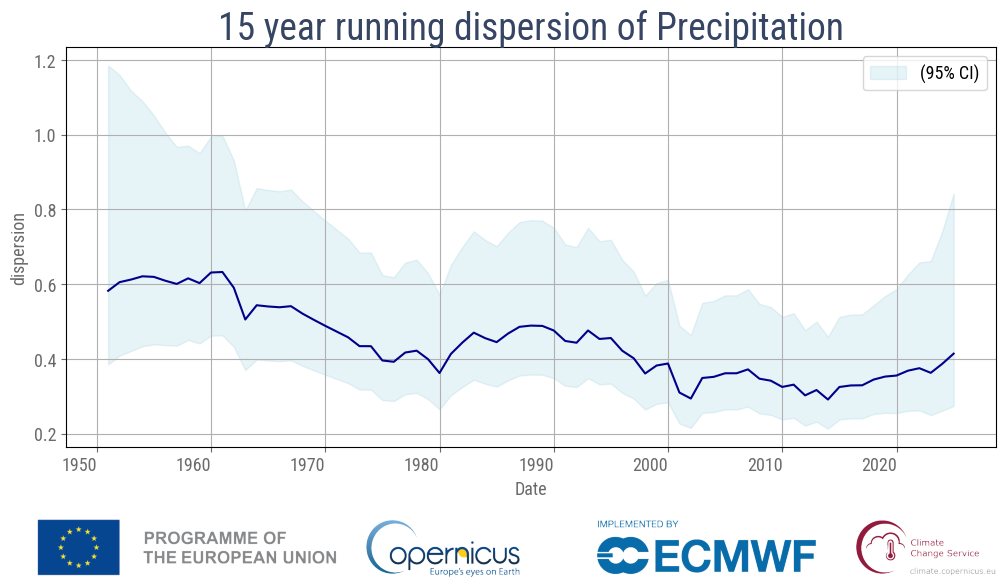

In [8]:
plot_timeseries_test(data=ts_ann_studyregion_15ym, datetime_col="year", value_col=value_col,
               title=f"15 year running {method} of {parameter}", x_label="Date", y_label=method, line_style='solid', ci=True);

## 3.2.d. Decide on which years to use if data is not homogeneous

### <font color='orange'>Specify the preferred time range based on the plot</font>

In [9]:
year_range = (1951, event_year)

### <font color='green'> Slice the annual time series on the given time range </font>

In [10]:
ts_ann_studyregion_subset = Utils.subset_gdf(gdf=ts_ann_studyregion, datetime_col="year", date_range=(year_range[0], year_range[1]))
ts_ann_studyregion_subset

,year,3_day_rolling_date,tp
0,1951,1951-08-23,72.611237
1,1952,1952-06-03,156.611115
2,1953,1953-10-05,56.201640
3,1954,1954-10-08,197.463386
4,1955,1955-09-30,209.504221
...,...,...,...
70,2021,2021-08-21,99.719591
71,2022,2022-06-21,56.343547
72,2023,2023-10-07,91.881753
73,2024,2024-07-01,127.713241


## 3.3 Conclude about the quality of ERA5
(and potentially other datasets) for the specific event definition and implications for the study results and the years to use, write into the output table in Notes & tables and the scientific report Section 2.1.
- a. For the region, check performance of the dataset, conclude on whether the data can be used with limited problems (“satisfactory”) or caution is necessary (“caution”) and conclude on a sentence in the scientific report
    - i. Temperature, include a statement on the performance of ERA5 for temperature based on Lopes et al. (2024) Conclusions from this paper are summarized here (attached to deliverable).
    - ii. Precipitation, include a statement on the performance of ERA5 for precipitation based on Lavers et al. (2022) Conclusions from this paper are summarized here (attached to deliverable).
    - iii. Other variable: if drought, base a general statement on temperature and precipitation, and/or perform literature study on the index and region specifically.
- b. For the use of years, using plots produced in Step 3.2.b visually check whether scale (temperature) or dispersion (precipitation) parameter show a trend and only use the stationary scale/dispersion-fit if the stationarity assumption is not obviously invalid in the sense that the trend is much greater than variability. Otherwise, a non-stationary scale- or
dispersion-parameter would be more appropriate (not part of OAO protocol). Add a sentence on caution on the results should be added to the scientific report Sec. 3.1 - see also Step 3.5b.iv

## 3.4 decide on which covariate to use
(normally this will only be GMST, smoothed with a 4-year running mean to remove the El Nino signal) and make sure the 4-year smoothed ERA5 GMST is updated up to the current month.
- a. C3S defines the 1850–1900 pre‑industrial global mean surface temperature to be 0.88 °C below the 1991–2020 ERA5 global average.

In [11]:
# # location of the gmst data
# gmst_url = "https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv"

# method = "mean"

In [12]:
# # import gmst data as seen in
# # https://github.com/maris-development/c3s-451/blob/development/input-notebooks/notebooks/gmst.ipynb

# datetime_col = "valid_time"
# gmst_col = "gmst"

# # read in the data
# gmst = (
#     pd.read_csv(
#         gmst_url,
#         na_values=["****", "***"],
#         index_col=0,
#         skiprows=1,
#         comment="#",
#     )
# )

# # unpivot the df
# gmst_monthly = (
#     pd.concat([
#         pd.DataFrame({
#             datetime_col: [datetime(y, i + 1, 1) for y in gmst.index],
#             gmst_col: gmst.iloc[:, i].values
#         })
#         for i in range(12)
#     ])
#     .sort_values(datetime_col)
#     .dropna(subset=[gmst_col])
#     .reset_index(drop=True)
# )
# gmst_monthly

# # change gmst column name to value_col
# gmst_monthly['t2m'] = gmst_monthly[gmst_col]
# gmst_monthly.drop(columns=[gmst_col], inplace=True)
# gmst_monthly = Utils.subset_gdf(gdf=gmst_monthly, datetime_col=datetime_col, date_range=(datetime(1951, 1, 1), event_end))
# gmst_monthly


In [ ]:
# commented temporarily for testing
bbox = (15, -104, 28, -90)
bbox = Utils.convert_bbox(*bbox)

event_end = datetime(2025, 6, 1)

your_api_key = '3cd17835-a572-4a0c-aaeb-334f01427616'
client = DataClient(cds_key=your_api_key, beacon_cache_url=None, beacon_token=None, mars_key=None)
gmst = client.gmst(bbox=bbox,time_range=(datetime(1951, 1, 1), event_end))

2026-01-09 11:00:45,815 INFO Request ID is 0c35e324-0e80-47cb-9bcb-ba135e744c2f
2026-01-09 11:00:46,425 INFO status has been updated to accepted
2026-01-09 11:01:00,138 INFO status has been updated to running
2026-01-09 11:01:08,672 INFO status has been updated to successful


PermissionError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\jasper\\AppData\\Local\\Temp\\tmpmd_y64gx.nc'

In [ ]:
# commented temporarily for testing
gmst = Process.weighted_values(gmst, 't2m')
gmst_monthly = Process.calculate_mean(gdf= gmst, value_col='t2m', groupby_col="valid_time")
gmst_monthly

,valid_time,t2m
0,1951-01-01,19.089640
1,1951-02-01,19.109057
2,1951-03-01,21.097123
3,1951-04-01,22.925354
4,1951-05-01,24.665964
...,...,...
895,2025-08-01,26.481283
896,2025-09-01,25.746792
897,2025-10-01,24.702556
898,2025-11-01,22.897662


In [ ]:
bbox = (15, -104, 28, -90)
bbox = Utils.convert_bbox(*bbox)

your_api_key = '3cd17835-a572-4a0c-aaeb-334f01427616'
gr_daily_clim = DataClient(your_api_key, beacon_cache_url='https://beacon-era5.maris.nl/').GET(parameter='Tmean', bbox=bbox, time_range=(datetime(1991, 1, 1), datetime(2020, 12, 31)), to_unit="c")

Connected to: https://beacon-era5.maris.nl/ server successfully
Beacon Version: 1.4.0
Connected to: https://beacon-era5.maris.nl/ server successfully
Beacon Version: 1.4.0
Fetching data from beacon cache for range: 1991-01-01 00:00:00 - 2020-12-31 00:00:00
Creating JSONQuery with from: FromTable(table='daily')
Running query: {"output": {"format": "parquet"}, "select": [{"column": "longitude", "alias": null}, {"column": "latitude", "alias": null}, {"column": "valid_time", "alias": null}, {"column": "t2m", "alias": null}], "filters": [{"and": [{"column": "longitude", "gt_eq": 256.0, "lt_eq": null}, {"column": "longitude", "gt_eq": null, "lt_eq": 270.0}, {"column": "latitude", "gt_eq": 15, "lt_eq": null}, {"column": "latitude", "gt_eq": null, "lt_eq": 28}]}, {"column": "valid_time", "gt_eq": "1991-01-01T00:00:00.000000", "lt_eq": "2020-12-31T00:00:00.000000"}], "distinct": null, "sort_by": null, "limit": null, "offset": null, "from": "daily"}


C:\Users\jasper\AppData\Local\Temp\ipykernel_22112\2452190064.py:5: DeprecationWarning: Use `self.fetch_data()` instead.
  gr_daily_clim = DataClient(your_api_key, beacon_cache_url='https://beacon-era5.maris.nl/').GET(parameter='Tmean', bbox=bbox, time_range=(datetime(1991, 1, 1), datetime(2020, 12, 31)), to_unit="c")


In [ ]:
gr_daily_clim = gr_daily_clim.sort_values(by="valid_time")
clim31d = Process.calculate_climatology(gr_daily_clim, value_col='t2m', padding=15, event_date=event_end)

print(clim31d)

         longitude  latitude        t2m  doy            geometry valid_time
0           -104.0     15.00  26.674801    1     POINT (-104 15) 2025-01-01
1           -104.0     15.25  26.616383    1  POINT (-104 15.25) 2025-01-01
2           -104.0     15.50  26.567694    1   POINT (-104 15.5) 2025-01-01
3           -104.0     15.75  26.524599    1  POINT (-104 15.75) 2025-01-01
4           -104.0     16.00  26.465950    1     POINT (-104 16) 2025-01-01
...            ...       ...        ...  ...                 ...        ...
1102660      -90.0     27.00  20.052126  365      POINT (-90 27) 2025-12-31
1102661      -90.0     27.25  19.747375  365   POINT (-90 27.25) 2025-12-31
1102662      -90.0     27.50  19.413397  365    POINT (-90 27.5) 2025-12-31
1102663      -90.0     27.75  19.070906  365   POINT (-90 27.75) 2025-12-31
1102664      -90.0     28.00  18.706905  365      POINT (-90 28) 2025-12-31

[1102665 rows x 6 columns]


In [ ]:
# changed this because studyregion and boundingbox are not matching for me
studyregion = gpd.read_file(os.path.join(your_save_directory, "sf_studyregion.shp"))
ts_clim31d_studyregion = Process.calculate_seasonal_cycle(clim31d=clim31d, studyregion=None, month_range=(1, 12), value_col='t2m', datetime_col="valid_time", event_end=event_end)[0]
monthly_clim31d_studyregion = (ts_clim31d_studyregion.resample("M", on="valid_time")['t2m'].mean().rename_axis("valid_time").reset_index())
monthly_clim31d_studyregion["valid_time"] = monthly_clim31d_studyregion["valid_time"].dt.to_period("M").dt.to_timestamp()
monthly_clim31d_studyregion

C:\Users\jasper\AppData\Local\Temp\ipykernel_22112\2741511744.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_clim31d_studyregion = (ts_clim31d_studyregion.resample("M", on="valid_time")['t2m'].mean().rename_axis("valid_time").reset_index())


,valid_time,t2m
0,2025-01-01,19.479525
1,2025-02-01,20.461810
2,2025-03-01,22.024680
3,2025-04-01,23.899676
4,2025-05-01,25.378904
5,2025-06-01,25.888586
6,2025-07-01,25.882606
7,2025-08-01,25.858806
8,2025-09-01,25.101920
9,2025-10-01,23.837135


In [ ]:
def fill_missing_gmst_with_climatology(
    gmst_monthly: pd.DataFrame,
    climatology: pd.DataFrame,
    time_col: str = "valid_time",
    gmst_value_col: str = "t2m",
    climatology_value_col: str = "t2m"
) -> pd.DataFrame:
    """
    Fill missing GMST monthly values using climatology + anomaly.

    This function:
    1. Ensures the datetime format.
    2. Sorts the GMST dataset by time.
    3. Builds a complete monthly date range up to the last available year December.
    4. Reindexes GMST onto this range.
    5. Fills any missing months using:
         GMST_missing = clim_missing_month + anomaly

    Parameters
    ----------
    gmst_monthly : pd.DataFrame
        GMST dataset with columns for timestamp and temperature.
    climatology : pd.DataFrame
        Monthly climatology dataset with same time/value columns.
    time_col : str, optional
        Name of the datetime column (default = "valid_time").
    gmst_value_col (str):
        Name of the value column in the GMST dataset (default = "t2m").
    climatology_value_col : str, optional
        Name of the temperature column (default = "t2m").

    Returns
    -------
    pd.DataFrame
        A DataFrame with a full monthly GMST time series and missing values filled.
    """

    # --- Ensure datetime ---
    gmst_monthly[time_col] = pd.to_datetime(gmst_monthly[time_col])
    climatology[time_col] = pd.to_datetime(climatology[time_col])

    # --- Sort GMST chronologically ---
    gmst_monthly = (
        gmst_monthly
        .sort_values(time_col)
        .reset_index(drop=True)
    )

    # --- Build complete monthly date range ---
    last_year = gmst_monthly[time_col].dt.year.max()
    full_range = pd.date_range(
        start=gmst_monthly[time_col].min(),
        end=pd.Timestamp(year=last_year, month=12, day=1),
        freq="MS"
    )

    # --- Reindex onto full range ---
    gmst_complete = (
        gmst_monthly
        .set_index(time_col)
        .reindex(full_range)
    )
    gmst_complete.index.name = time_col

    # --- Fill missing values using clim + anomaly ---
    missing_indices = gmst_complete[gmst_complete[gmst_value_col].isna()].index

    for idx in missing_indices:
        # previous available GMST
        prev_idx = gmst_complete.index[gmst_complete.index < idx][-1]
        last_gmst = gmst_complete.loc[prev_idx, gmst_value_col]

        # climatology values
        prev_clim = climatology.loc[
            climatology[time_col].dt.month == prev_idx.month, climatology_value_col
        ].iloc[0]

        missing_clim = climatology.loc[
            climatology[time_col].dt.month == idx.month, climatology_value_col
        ].iloc[0]

        # anomaly
        anomaly = last_gmst - prev_clim

        # fill missing value
        gmst_complete.loc[idx, gmst_value_col] = missing_clim + anomaly

    return gmst_complete.reset_index().rename(columns={"index": time_col})


In [ ]:
gmst_monthly_filled = fill_missing_gmst_with_climatology(gmst_monthly, monthly_clim31d_studyregion)
gmst_yearly = gmst_monthly_filled.groupby(gmst_monthly_filled["valid_time"].dt.year)['t2m'].mean().reset_index()
# calculate the rolling mean Rolling windows of 4 years or should we take 5 years?, taking 2 years before, same year, ad 1 year after
#For last year it take 2 years before and same year
gmst_yearly_rolled = Process.calculate_rolling_window(gdf=gmst_yearly, value_col='t2m', datetime_col="valid_time", window=4, min_periods=2, centering=True, method="mean")
gmst_yearly_rolled_subset = Utils.subset_gdf(gdf=gmst_yearly_rolled, datetime_col="valid_time", date_range=(year_range[0], year_range[1]))
gmst_yearly_rolled_subset = gmst_yearly_rolled_subset.rename(columns={"valid_time": "year"})
gmst_yearly_rolled_subset

,year,t2m
0,1951,22.648846
1,1952,22.694968
2,1953,22.653786
3,1954,22.588227
4,1955,22.560752
...,...,...
70,2021,23.733000
71,2022,23.821161
72,2023,23.929335
73,2024,24.042760


In [ ]:
# # Ensure datetime
# gmst_monthly["valid_time"] = pd.to_datetime(gmst_monthly["valid_time"])
# monthly_clim31d_studyregion["valid_time"] = pd.to_datetime(monthly_clim31d_studyregion["valid_time"])

# # Sort GMST
# gmst_monthly = gmst_monthly.sort_values("valid_time").reset_index(drop=True)

# last_year = gmst_monthly["valid_time"].dt.year.max()

# full_range = pd.date_range(
#     start=gmst_monthly["valid_time"].min(),
#     end=pd.Timestamp(year=last_year, month=12, day=1),
#     freq="MS"  # Month start
# )

# # Reindex GMST to this complete range
# gmst_complete = gmst_monthly.set_index("valid_time").reindex(full_range)
# gmst_complete.index.name = "valid_time"

# # Fill missing values using climatology + anomaly
# for idx in gmst_complete[gmst_complete["t2m"].isna()].index:
#     # Previous available GMST
#     prev_idx = gmst_complete.index[gmst_complete.index < idx][-1]
#     last_gmst = gmst_complete.loc[prev_idx, "t2m"]

#     # Climatology for previous month
#     prev_clim = monthly_clim31d_studyregion.loc[
#         monthly_clim31d_studyregion["valid_time"].dt.month == prev_idx.month,
#         "t2m"
#     ].iloc[0]

#     # Calculate anomaly
#     anomaly = last_gmst - prev_clim

#     # Climatology for missing month
#     missing_clim = monthly_clim31d_studyregion.loc[
#         monthly_clim31d_studyregion["valid_time"].dt.month == idx.month,
#         "t2m"
#     ].iloc[0]

#     # Fill missing GMST
#     gmst_complete.loc[idx, "t2m"] = missing_clim + anomaly

# # Reset index to column
# gmst_monthly_up = gmst_complete.reset_index()
# gmst_monthly_up


In [ ]:
# # calculate the rolling mean
# gmst_monthly_rolled = calculate_rolling_window(gdf=gmst_monthly, value_col=gmst_col, datetime_col=datetime_col,
#                                                window=48, min_periods=24, centering=True, method=method)
# # select only the specified years
# gmst_monthly_rolled = subset_gdf(gdf=gmst_monthly_rolled, datetime_col=datetime_col, year_range=year_range)
# gmst_monthly_rolled

# gmst_yearly, rolled_gdf = calculate_yearly_value(gdf=gmst_monthly_rolled, value_col=gmst_col, datetime_col=datetime_col, yearly_value=method)
# gmst_yearly

In [ ]:
merged_t2m_gmst = pd.merge(ts_ann_studyregion_subset, gmst_yearly_rolled_subset, left_on="year", right_on="year", how="inner")
# calculate anomaly relative to event year
ref_val = merged_t2m_gmst.loc[merged_t2m_gmst["year"] == event_year, value_col].values[0]
merged_t2m_gmst_anomaly = merged_t2m_gmst.copy()
merged_t2m_gmst_anomaly["gmst"] = merged_t2m_gmst_anomaly[value_col] - ref_val
merged_t2m_gmst_anomaly.to_csv("../data/gmst_t2m.csv", index=False)
merged_t2m_gmst_anomaly

,year,3_day_rolling_date,tp,t2m,gmst
0,1951,1951-08-23,72.611237,22.648846,-130.366293
1,1952,1952-06-03,156.611115,22.694968,-46.366415
2,1953,1953-10-05,56.201640,22.653786,-146.775890
3,1954,1954-10-08,197.463386,22.588227,-5.514144
4,1955,1955-09-30,209.504221,22.560752,6.526690
...,...,...,...,...,...
70,2021,2021-08-21,99.719591,23.733000,-103.257940
71,2022,2022-06-21,56.343547,23.821161,-146.633984
72,2023,2023-10-07,91.881753,23.929335,-111.095778
73,2024,2024-07-01,127.713241,24.042760,-75.264290


## 3.5 Apply statistical method
information for decisions on fit properties:
- a. fit data to statistical model, and check, at least by eye, that this fit agrees with the observed data points. Show this in a figure.
    - i. Gauss - soft extremes with low return periods that are not in the tail. Threshold μ (mu), scale parameter σ (sigma). Usually used for seasonal averages.
    - ii. GEV - largest observation from a large sample: annual/seasonal maximum, block maximum. Location parameter μ, scale parameter σ, shape parameter ξ. Usually used for 1-day to 14-day averages, annual (or seasonal) maximum
    - iii. For in-depth studies potentially use Lognormal, possibly better for precipitation.
- b. shift/scale with GMST or other proxy for anthropogenic forcing
    - i. for temperature extremes the distribution shifts due to global warming without changing the shape (variability: σ, ξ constant).
    - ii. for precipitation (and wind) extremes the distribution scales (variability over mean: dispersion parameter σ/μ and ξ constant).
    - iii. For precipitation with Lognormal use shift
    - iv. Use the visual check of scale or dispersion parameter (done in Step 3.3b): use the stationary scale/dispersion-fit if the stationarity assumption is not obviously invalid. Otherwise using a non-stationary scale- or dispersion-parameter would be more appropriate, and a sentence on caution on the results should be added to the scientific report Section. 3.1
    - v. decide on which covariate to use (normally GMST, smoothed with a 4-year running mean or a similar method to remove the El Nino signal)
    - vi. Include the datapoint of the event under study in the fit

### <font color='orange'>Please specify the following variables<font>

In [ ]:
%%R -i event_year -i value_col
dist = "gev" #norm 
fit_type = "fixeddisp" #shift for temp, fixeddisp for precipitation
covnm = "gmst"
lower = FALSE
cooling_offset = 1.3 #fixed for now

In [ ]:
%%R -i merged_t2m_gmst_anomaly 

df <- merged_t2m_gmst_anomaly

mdl <- fit_ns(dist = dist, type = fit_type, data = df, varnm = value_col, covnm = covnm, lower = lower, ev_year = event_year)

# the factual climate should have the GMST of the year in which the event occurred
cov_factual <- data.frame(gmst = df$gmst[df$year == event_year])

# the counterfactual climate can represent any alternative climate (WWA always uses a preindustrial climate, 1.3C cooler than the present)
cov_counterfactual <- data.frame(gmst = df$gmst[df$year == event_year] - cooling_offset)

Error in optim(par = init, ns_loglik, cov = cov, x = x, dist = dist, fittype = type,  : 
  non-finite finite-difference value [3]


RInterpreterError: Failed to parse and evaluate line '\ndf <- merged_t2m_gmst_anomaly\n\nmdl <- fit_ns(dist = dist, type = fit_type, data = df, varnm = value_col, covnm = covnm, lower = lower, ev_year = event_year)\n\n# the factual climate should have the GMST of the year in which the event occurred\ncov_factual <- data.frame(gmst = df$gmst[df$year == event_year])\n\n# the counterfactual climate can represent any alternative climate (WWA always uses a preindustrial climate, 1.3C cooler than the present)\ncov_counterfactual <- data.frame(gmst = df$gmst[df$year == event_year] - cooling_offset)\n'.
R error message: 'Error in optim(par = init, ns_loglik, cov = cov, x = x, dist = dist, fittype = type,  : \n  non-finite finite-difference value [3]'

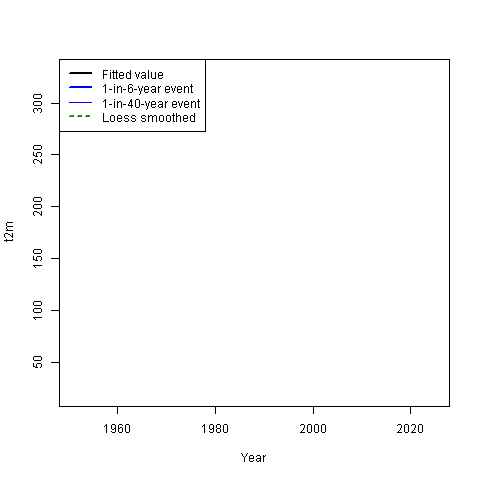

In [ ]:
%%R

# what does the fitted trend look like over time?
# `add_loess = T` will add a nonparametric smoother - use this to check whether the fitted model captures the observed trend
plot_trend(mdl, add_loess = T, ylim = c(20,330))

Error in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,  : 
  invalid 'x'


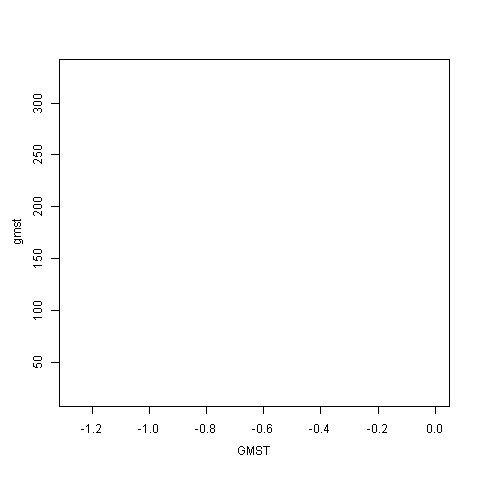

RInterpreterError: Failed to parse and evaluate line '# what does the fitted trend look like vs GMST?\nplot_covtrend(mdl, xcov = covnm, add_loess = T, ylim = c(20,330))\n'.
R error message: "Error in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,  : \n  invalid 'x'"

In [ ]:
%%R
# what does the fitted trend look like vs GMST?
plot_covtrend(mdl, xcov = covnm, add_loess = T, ylim = c(20,330))

In [ ]:
%%R
# How well does the model fit the data?
# the points should be close to the line - if they're not within the shaded region, the model is a poor fit
plot_returnlevels(mdl, cov_f = cov_factual, cov_cf = cov_counterfactual, xlim = c(1,10000),  ylim = c(20,330))

## 3.6 Observed probability and trend detection:
- a. Note down decision on the statistical method (see Step 3.5) in the Notes & Tables document
- b. Note dGMST, i.e. the difference between GMSTevent and GMSTpast, based on the Global Warming Index (https://www.globalwarmingindex.org) in 1 digits, e.g. 1.3 (this is the value in 2025). Check once a year that this value is still valid.
- c. Use all observational/reanalysis datasets that passed the quality checks (years see Step 3.2d). This is likely ERA5 and potentially also a station data time series.
- d. Note down/save variability or variability over mean (σ or σ/μ) and shape parameter ξ (for GEV) of the fit
- e. Note down return period in the current climate Yevent, e.g., 2025, and decide on the single rounded value that will be used for communication purposes and the model analyses – write this in the output table in Notes & Tables (bottom row). Rounding should correspond to the order of magnitude of the bandwidth, e.g., 13.876 (minimum 8.124 to maximum 20.573) should then be 14 (8-21.)
    - i. if necessary, make decision on using e.g. lower bound in case of too extreme return period. Then use this value in models analysis as well.
- f. Note down the threshold value corresponding to the event
- g. Note down probability ratio PR for dGMST, and change in intensity ΔI (absolute value for temperature, % for precipitation)

In [ ]:
%%R
# use the built-in function to bootstrap the model results
boot_res <- boot_ci(mdl, cov_f = cov_factual, cov_cf = cov_counterfactual)

print(boot_res)

# save as a .csv to look at them later
write.csv(boot_res, "../data/res-obs_era5.csv")

In [ ]:
%%R

# comment out the top & bottom lines to see what the figures look like before saving them
png("../data/fig_obs-trend_era5.png", height = 480, width = 480); {
    plot_trend(mdl, add_loess = T, ylim = c(18,33), ylab = "Mean temperature (degC)", lwd = 2)
}; dev.off()

png("../data/fig_obs-gmsttrend_era5.png", height = 480, width = 480); {
    plot_covtrend(mdl, xcov = "gmst", add_loess = T, ylim = c(18,33), ylab = "Mean temperature (degC)", lwd = 2)
}; dev.off()

png("../data/fig_obs-returnlevels_era5.png", height = 480, width = 480); {
    plot_returnlevels(mdl, cov_f = cov_factual, cov_cf = cov_counterfactual, ylim = c(18,33), ylab = "Mean temperature (degC)",
                     legend_labels = c("2025", "Preindustrial"))
}; dev.off()

In [ ]:
##Input value, default value from table

In [ ]:
%%R
rp_factual <- return_period(mdl, x = 89, fixed_cov = cov_factual)
rp_counterfactual <- return_period(mdl, x = 89, fixed_cov = cov_counterfactual)

cat("Return period (factual):\n")
print(rp_factual)
cat("\nReturn period (counterfactual):\n")
print(rp_counterfactual)


In [ ]:
%%R

# try fitting different distributions to compare which actually fits better
mdl_gev <- fit_ns(dist = "gev", type = "shift", data = df, varnm = value_col, covnm = "gmst", lower = F)
mdl_norm <- fit_ns(dist = "norm", type = "shift", data = df, varnm = value_col, covnm = "gmst", lower = F)

# use AIC to identify the model that fits better (lower score is better)
cat("AIC (GEV):", aic(mdl_gev), "\n")
cat("AIC (Normal):", aic(mdl_norm), "\n")

In [ ]:
%%R

# the 'rwwa' package has a built-in function to transform all points into the factual or counterfactual climate
y_factual <- stransform(mdl, fixed_cov = cov_factual)
y_counterfactual <- stransform(mdl, fixed_cov = cov_counterfactual)

# it can also extract the model parameters for a fixed value of the covariates
pars_factual <- ns_pars(mdl, fixed_cov = cov_factual)
pars_counterfactual <- ns_pars(mdl, fixed_cov = cov_counterfactual)

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# we can therefore plot the density of the temperatures as they would have been in today's climate, or in the counterfactual climate
par(lwd = 2)
plot(density(y_factual), col = "red3", ylim = c(0, 0.03), main = "", 
     xlab = "Mean temperature (degC)")

# factual model fit (dashed line)
x <- seq(15, 35, 0.1)
lines(x, devd(x, loc = pars_factual$loc, scale = pars_factual$scale, shape = pars_factual$shape),
      type = "l", col = "red3", lty = 2)

# counterfactual density and fit
lines(density(y_counterfactual), col = "blue2")
lines(x, devd(x, loc = pars_counterfactual$loc, scale = pars_counterfactual$scale, shape = pars_counterfactual$shape),
      type = "l", col = "blue2", lty = 2)

# add ticks for observed temperatures
rug(df$tmax, lwd = 3)

## 3.7 Literature review specific on the investigation of other possible climatic drivers of the event (modes of natural variability) for regions where they are important.
Steps a.i, b, c and d are essential, but if time allows it is useful to additionally do some of the optional steps.
- a. First find out what drivers influence (extremes in) the event type at the event location and its variability and trend, for example, using the following sources (see also Sec. 6a. Literature research)
    - i. Visually inspect teleconnection maps for average response of T/precip per month during years of high index https://confluence.ecmwf.int/display/COPSRV/ENSO+impacts+on+Europe and describe average impact over the region assessed if it is an ENSO year (see next step). In the maps “Global effects - temperature and precipitation” use
        - 7.a.i.1. Month of interest
        - 7.a.i.2. Variable of interest (top figures: temperature, bottom figures: precipitation)
        - 7.a.i.3. El Nino (figures left) or La Nina (figures right)
    - ii. OPTIONAL: Via IPCC AI chat https://www.climateqa.com/ e.g. by asking the question “what climate drivers influence the extremes, variability and trend of rainfall in Somalia” and, if El Niño is the answer, “what is the influence of El Niño on rainfall in Somalia?”. Any content derived from AI must be quality assured before inclusion in output.
    - iii. OPTIONAL: Search generally or in scholar.google.com for literature. ClimateQA can be used to summarise papers, in conjunction with careful proof reading of the output.
    - iv. OPTIONAL: Potentially ask this to the local experts.
- b. Assess what the current status of those drivers is on the current event. If e.g. ENSO is a driver, but ENSO is currently in a neutral state then, whilst ENSO influences the variability of the time series, it did not play a prominent role in the magnitude of the current event. Check the following and download the relevant graphics for the current status of ENSO and IOD.
    - i. ENSO
    - ii. IOD
- c. Decide whether an in-depth study should be considered and communicate this with the rest of the Team.
    - i. Investigate influence of modes of natural variability e.g. ENSO as 2nd covariate. The procedures in python notebook X can be followed.
- d. Summarise findings and decisions in scientific report Section 3.3 and summarise the findings in one sentence for the fact sheet.